# Machine Learning (ML) for Biosignature Detection in Icy Ocean Worlds:

## `mlbiosig` Python Package Demonstration & Usage Examples:

### Introduction:

This notebook serves as a demonstration of the `mlbiosig` Python package, which was developed for the purposes of providing a reproducible and interpretable ML pipeline for biotic-abiotic classifiction of pyrolysis-Gas Chromatography-Mass Spectrometry (py-GC-MS) sample data. `mlbiosig` offers modules for preprocessing raw py-GC-MS data into py-MS vectors stacked into an $m/z$ feature matrix, engineering and cleaning those features, and training four binary classifiers (Logistic Regression, SVC, Random Forest, XGBoost). Following training, the four classifiers are evaluated using F1 and ROC-AUC scores, and interpretability analyses included in `mlbiosig` help connect ML predictions to the the underlying geochemistry of the $m/z$ fragment ions.

**Reproducibility:** The analyses in this notebook are reproducible using the given code and data within the root repository. However, due to the stochastic nature of hyperparameter tuning and classifier training, the exact hyperparameters, model performance metrics, and subsequent interpretability might vary between runs. Nevertheless, the overall figures and geochemical conclusions remain reproducible.

### Imports:

In [ ]:
# General imports needed alongside mlbiosig:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  # plotting
from sklearn.decomposition import PCA  # PCA

### Loading py-MS CSV Data:

py-GC-MS sample CSV files must be organised within a `data/` folder containing `biotic/` and `abiotic/` subfolders as per the sample class label. To acquire the full sample set, filepaths and labels for each sample CSV file are obtained as shown below:

```python
from mlbiosig.preprocess import samples_labels
filepaths, labels = samples_labels()
```
As this demonstration will include a reduced dataset of $28$ samples ($14$ biotic and $14$ abiotic) for clarity, the cell below is used purely to load this subset accordingly.

In [93]:
from get_demo_samples import demo_samples

filepaths, labels = demo_samples(sample_path="demo_samples.txt")

### Generating, Building & Engineering py-MS Features:

py-MS features construction and engineering prior to ML classification is automatically handled by `mlbiosig`. Engineering steps include the removal of instrumental and background contaminants, dropping low-variance features that most likely encode noise, and label encoding the target variable assigning biotic/abiotic class. An $80:20$ training/testing split of the feature and target is applied, producing ML classification-ready features and target sets. 

To explore these implementations in detail, please refer to the [preprocessing](../mlbiosig_dev/01_preprocessing.ipynb) and [feature engineering](../mlbiosig_dev/02_feature_engineering.ipynb) development notebooks.

In [94]:
from mlbiosig.preprocess import build_features
from mlbiosig.feature_engineering import engineer_features

# Build py-MS feature matrix:
# flags only necessary if there are anticipated errors in CSV files
feature_matrix, flags = build_features(filepaths, labels)

# Engineer py-MS feature matrix for subsequent training:
X_train, X_test, y_train, y_test, le, selector = engineer_features(feature_matrix)

Preprocessing py-GC-MS samples:   0%|          | 0/28 [00:00<?, ?sample/s]

### PCA:

Principal Component Analysis (PCA) provides visual exploration of the engineered py-MS features space of samples prior to classification. The number of PCs is restricted to $k=2$ based on prior Scree plot analysis, however this can be adjusted as desired.

In [95]:
# Initialise principal components (PCs):
k = 2
pca = PCA(n_components=k)

# Reduce training data into k = 2:
X_train_pca = pca.fit_transform(X_train)
explained_var = pca.explained_variance_ratio_

Data points are coloured by sample type rather than by sample class using a user-defined dictionary mapping sample filenames to their corresponding chemical descriptions. For example `SHEW` corresponds to microbial *Shewanella* samples. This is also fully customisable and can accomodate any laboratory's sample naming convention, as demonstrated below.

In [96]:
# Definining sample-type categories based on CSV filename:
cats = {
    "SHEW": "Shewanella",
    ("_CH", "CHLOR"): "Chlorella",
    "SP": "Spirulina",
    ("KEROGEN", "WC", "WL", "CBN", "CD3", "LF1", "RMP1", "GRS"): "Kerogen",
    ("BARLEY", "CHESTNUT", "CW", "PINE", "PB", "RICE", "EUCALYPTUS"): "Biochar",
    "CELLULOSE": "Cellulose",
    ("PP", "PS", "PVC"): "Plastics",
    ("AMBER", "FRANK", "DAMMAR", "MYRRH", "ROSIN"): "Resin",
    ("WAX", "CARNAUBA", "MICRO"): "Wax",
    ("LOWVOL", "HIGHVOL", "DM_"): "Coal",
    ("MURCHISON", "WINC", "ALLENDE", "NWA"): "Meteorite",
    ("CACO3", "GOET", "MAG", "KAOL", "NONT", "SERP"): "Mineral",
}

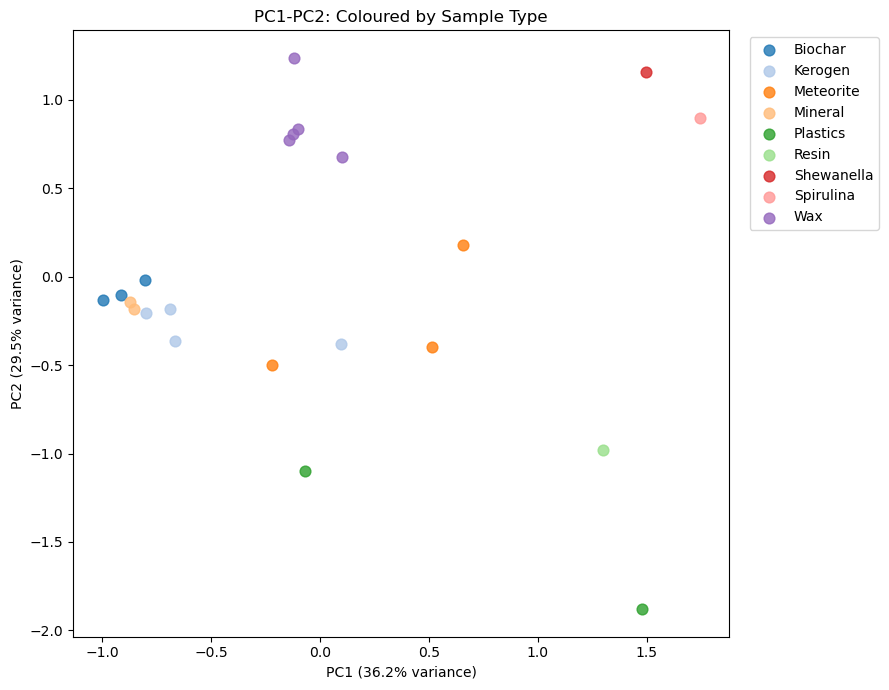

In [97]:
from mlbiosig.feature_engineering import classify_samples, plot_loadings

# Plotting PC1 and PC2 and colour-coding different sample categories
plt.figure(figsize=(9, 7))
sample_type = [classify_samples(name, cats) for name in X_train.index]
colors = plt.get_cmap("tab20").colors  # unique colors

for colour, group in zip(colors, np.unique(sample_type)):
    mask = np.array(sample_type) == group
    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        color=colour,
        label=group,
        s=60,
        alpha=0.8,
    )


plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% variance)")
plt.title("PC1-PC2: Coloured by Sample Type")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Features that are well-engineered shoudl produce well-formed sample type clusters, such that samples of the same chemical origin appear to cluster within similar regions of PC1-PC2 space. If samples of the same type do not appear to cluster well, this could be indicative of discrepancies between analytical sample runs or unaccounted instrumental artefacts.

To interpret the above plot, PC1 and PC2 are axes that capture the directions of maximum variance in the py-MS feature matrix. When using `mlbiosig` in this work, PC1 from negative to positive has been observed to encode the transition from inert carbon to hydrocarbon-rich sample chemistry, while PC2 from negative to positive appears to encode a gradient from biologically active to geochemically fossilised matter.

To better quantify which $m/z$ fragment ions determine the position of samples along PC1 and PC2, loadings denoted as  $l_{ab}$ can be plotted for a given PC.  $l_{ab}$ quantifies how strongly each $m/z$ feature contributed towards a sample's position along a given PC such that $l_{ab} \in [-1, +1]$. 15 loadings are plotted by default for a chosen PC where, for example, both PC1 and PC2 $l_{ab}$ values are plotted. Nevertheless, the number of PCs and loadings can be customised.

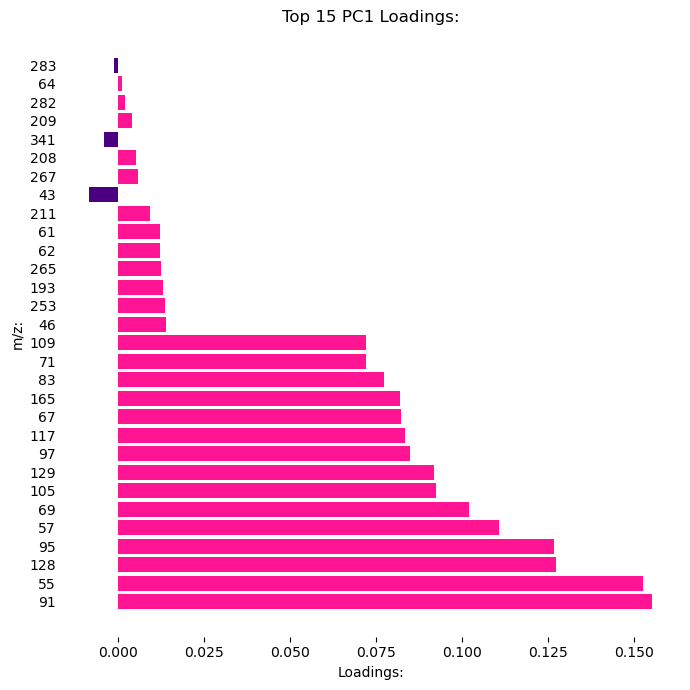

In [98]:
# Loadings to find contribution of each m/z feature to PC1 & PC2:
loadings = (pca.components_.T) * (np.sqrt(explained_var))
loadings_df = pd.DataFrame(
    loadings,  # rows = m/z, columns = PCs
    index=X_train.columns,  # m/z values
    columns=["PC1", "PC2"],
)

# Plot top 15 PC1 loadings:
pc1_loadings = loadings_df["PC1"].sort_values()
plot_loadings(pc1_loadings, "PC1")

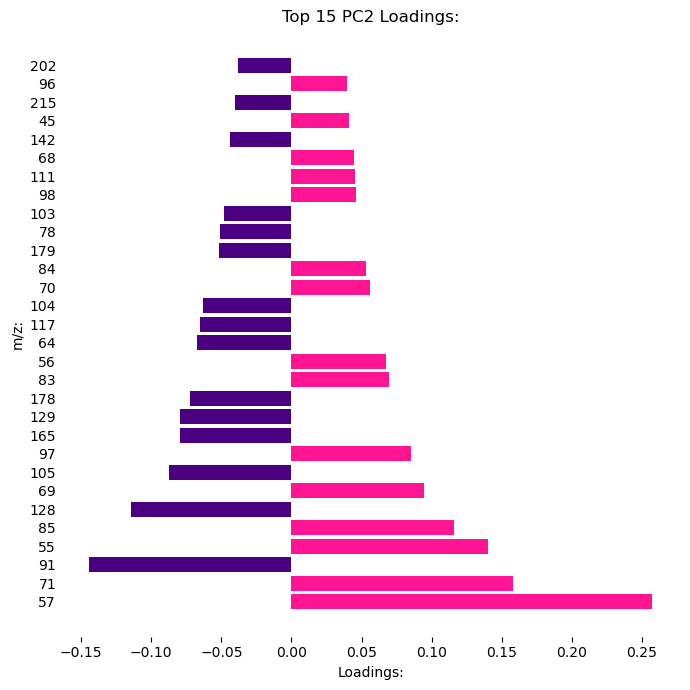

In [99]:
# Plot top 15 PC2 loadings:
pc2_loadings = loadings_df["PC2"].sort_values()
plot_loadings(pc2_loadings, "PC2")

Analysing the $m/z$ features (fragment ions) is useful further down the pipeline, especially during interpretability. In this demonstration, PC1 ($39\%$ variance) is driven by a mixture of heavier and lighter hydrocarbon $m/z$ fragment ions, while PC2 ($29\%$ variance) is dominated by lighter hydrocarbon fragments. Other interesting observations to note are the $m/z$ values that indicate the strong influence of known compounds such as napathalene ($m/z$ $128$) in PC2.

### Training & Evaluating Four Classifiers:

Logistic Regression (LR), SVC, Random Forest (RF), and XGBoost are automatically trained using `mlbiosig`. This includes a coarse-to-fine hyperparameter tuning strategy, which first identifies well-performing hyperparamete regions during a randomised search followed by a narrower grid search to obtain the the optimal hyperparameter combinations. All tuning is assessed against a cross-validated F1 score given the small dataset of only $28$ samples. Each fitted classifier is then evaluated against the testing set using F1 and ROC-AUC scores. 

To explore the hyperparameter search ranges and training implementation, please refer to the [ML classification](../mlbiosig_dev/03_balanced_ml_classification.ipynb) development notebook.

In [100]:
from mlbiosig.classifiers import train_evaluate_classifiers

# Train and evaluate all four classifiers:
results, models, grid_searches = train_evaluate_classifiers(
    X_train, X_test, y_train, y_test
)


Coarse Hyperparameter Search: RandomizedSearchCV


Random Search:   0%|          | 0/4 [00:00<?, ?model/s]


[1/4] Logistic Regression
    Best CV F1: 0.733
    Parameters: {'solver': 'lbfgs', 'C': 0.1}

[2/4] SVC
    Best CV F1: 0.677
    Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 1}

[3/4] Random Forest
    Best CV F1: 0.541
    Parameters: {'max_depth': 50, 'min_samples_split': 5, 'n_estimators': 258}

[4/4] XGBoost
    Best CV F1: 0.460
    Parameters: {'learning_rate': 0.01, 'max_depth': None, 'n_estimators': 129}

Fine Hyperparameter Search: GridSearchCV


Grid Search:   0%|          | 0/4 [00:00<?, ?model/s]


[1/4] Logistic Regression
    Best CV F1: 0.733
    Parameters: {'C': 0.05, 'solver': 'lbfgs'}

[2/4] SVC
    Best CV F1: 0.743
    Parameters: {'C': 2, 'gamma': 'scale', 'kernel': 'rbf'}

[3/4] Random Forest
    Best CV F1: 0.541
    Parameters: {'max_depth': 45, 'min_samples_split': 3, 'n_estimators': 158}

[4/4] XGBoost
    Best CV F1: 0.460
    Parameters: {'learning_rate': 0.005, 'max_depth': None, 'n_estimators': 129}

Test-set Evaluation:


Evaluating Models:   0%|          | 0/4 [00:00<?, ?model/s]



Logistic Regression Results:
    CV F1 Score: 0.733
    F1 Score: 0.667
    ROC-AUC Score: 0.667


SVC Results:
    CV F1 Score: 0.743
    F1 Score: 0.400
    ROC-AUC Score: 0.667


Random Forest Results:
    CV F1 Score: 0.541
    F1 Score: 0.400
    ROC-AUC Score: 0.778


XGBoost Results:
    CV F1 Score: 0.460
    F1 Score: 0.667
    ROC-AUC Score: 0.667


In this demonstration, LR, SVC, and RF show signs of overfitting, where SVC experiences a test F1 drop of more than $0.3$ relative to its CV F1 score. On the other hand, XGBoost generalises better to the test set, achieving a higher test F1 score of $\sim 0.67$ in comparison to its CV F1 score. RF achieves the highest ROC-AUC score amongst all four classifiers, implying strong discrimination across varying decisions thresholds despite a lower test F1 score.

### Performance Evaluation: Visualisation

Confusion matrices can help visualise the distribution of correct and incorrect predictions for each classifier, which is incredibly important in terms of inspectinng for false positives and false negatives.

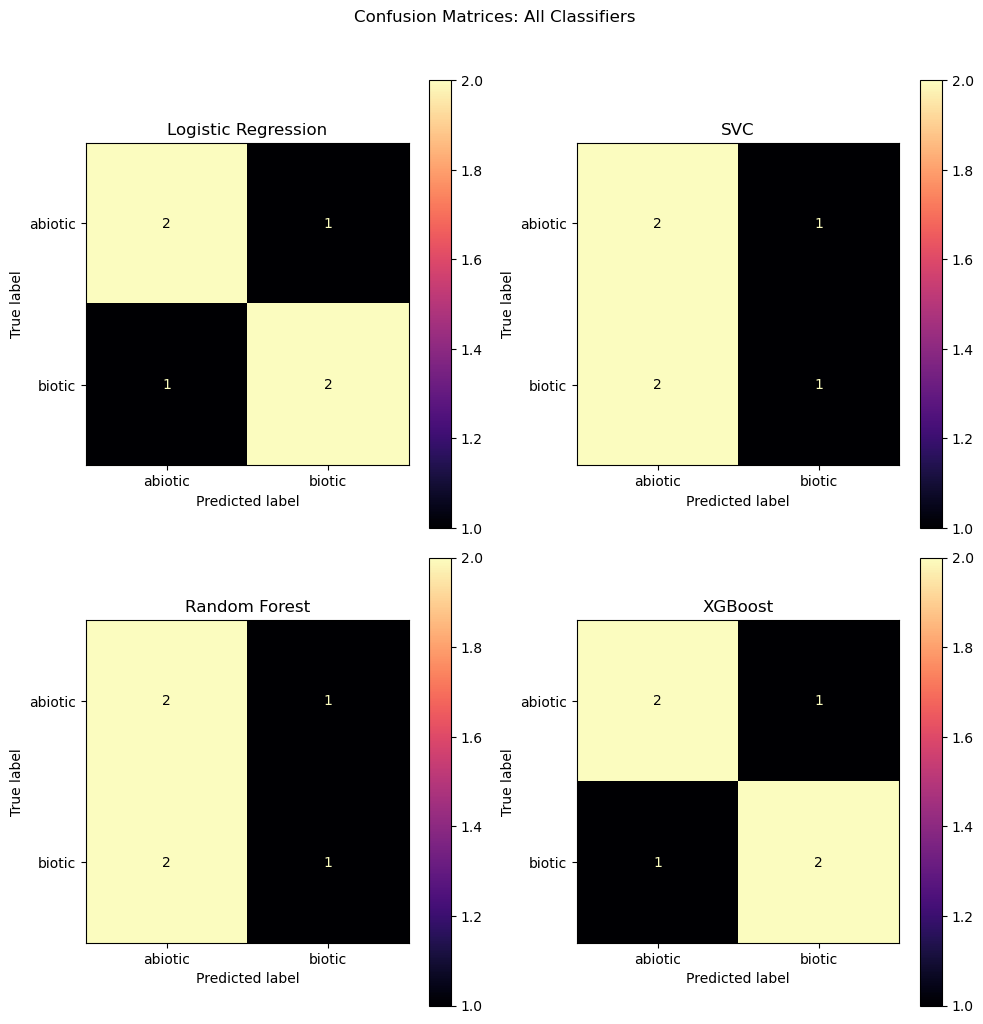

In [101]:
from mlbiosig.evaluate import plot_confusion_matrices

plot_confusion_matrices(models, X_test, y_test, le)

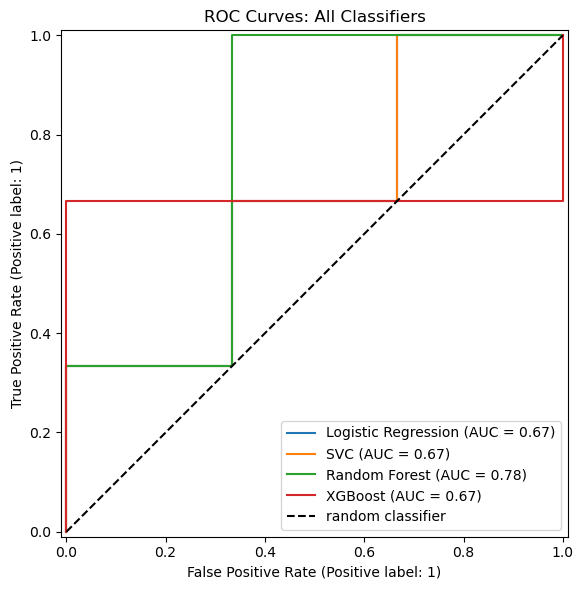

In [102]:
from mlbiosig.evaluate import plot_roc_curves

plot_roc_curves(models, X_test, y_test)

### Interpretability Analysis:

For the purposes of this demonstration, LR and RF will serve as the linear and non-linear tree-based models, respectively, to be applied with the interpretability tools available in `mlbiosig`. As LR achieved a relatively modest test F1 and ROC-AUC score of $\sim 0.67$, it's identified $m/z$ features can be treated as potentially geochemically-motivated. RF, however, yielded a low test F1 score of $0.4$ from possible overfitting while also achieving the highest ROC-AUC score ($0.78$).

To understand the underlying algorithmic decisions of `mlbiosig`'s interpretability tools, please refer to the [evaluation](../mlbiosig_dev/05_evaluation.ipynb) development notebook.

##### Permutation Importance of a Linear Model: Logistic Regression

Permutation importance scores capture the drop in F1 score when a given $m/z$ feature's intensity values are randomly permuted and break its association to a given class label i.e., biotic or abiotic. Large F1 score drops indicate that a classifier heavily relies on an $m/z$ feature for correct biotic-abiotic prediction, and that the $m/z$ fragment ion itself could encode substantive geochemical information. Scores are computed across `n_repeats=30` random permutations in `mlbiosig`.

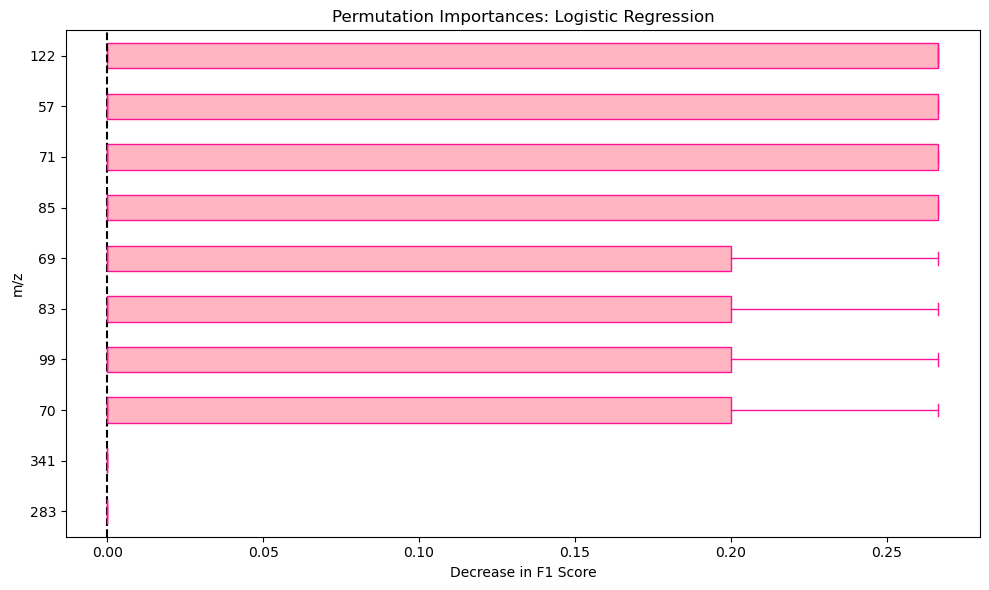

In [103]:
from mlbiosig.evaluate import plot_permutation_importance

plot_permutation_importance(
    models["Logistic Regression"], X_test, y_test, "Logistic Regression"
)

For LR, permuting the intensity values of $m/z$ $57, 71, 85,$ and $122$ results in an F1 score drop reaching $0.25$ and is quite significant. Groups of $m/z$ features appear to have identifical F1 score drops due to the strong multicollinearity retained in the $m/z$ feature set, in order to keep the underlying fragmentation patterns between $m/z$ ions. As a result, correlated $m/z$ features may produce the same importance scores when individually permuted.

##### Permutation Importance of a Tree-Based Ensemble: Random Forest

As previously discussed, strong multicollinearity creates relationships between correlated $m/z$ features. For tree-based models, permutation importance can collapse and default to zero. When a single feature is permuted, the classifier substitutes its reliance on that feature to its correlated features and thus renders it unimportant.`mlbiosig` bypasses this phenomena by clustering correlated features hierarchically and evaluating permutation importance on a representative $m/z$ feature from each cluster. User's must manually tune and choose their desired  clustering threshold, $t$, to balance cluster size against granularity. Dendrogram plotting functionalities are provided by `mlbiosig` for this purpose.

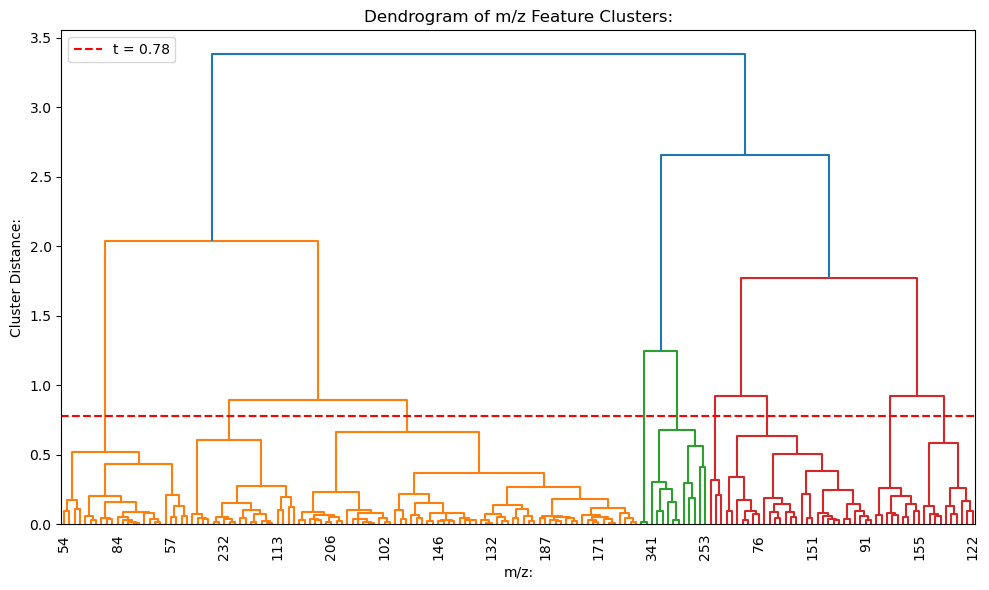

In [111]:
from mlbiosig.evaluate import cluster_features, plot_dendrogram

t = 0.78
_, distance_linkage = cluster_features(X_train, t)
plot_dendrogram(X_train, distance_linkage, t)

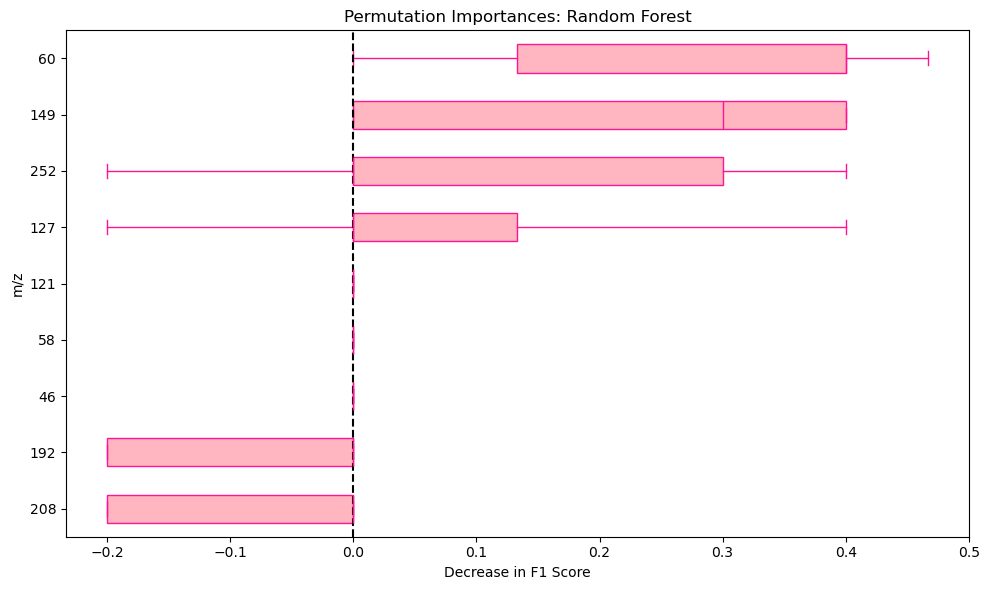

In [112]:
from mlbiosig.evaluate import plot_permutation_importance_tree

plot_permutation_importance_tree(
    grid_searches, X_train, X_test, y_train, y_test, "Random Forest", t
)

It appears that $m/z$ $60$ has the largest F1 score drop (as high as $\sim 0.4$), and therefore demonstrates strong reliance on this feature for RF predictions. On the other hand, $m/z$ $192$ and $208$ instead produce F1 score increases reaching as large as $0.2$ when permuted, suggesting that these features introduce noise into RF predictions rather than discriminative signals. Moreover, $m/z$ $127$ and $252$ vary across the $30$ permuation repeat, resulting in either an increase or decrease in F1 score which should be cautiously interpreted.

##### Coefficient Analysis: Logistic Regression

Coefficient analysis is applicable to linear classifiers such as LR and SVC (when a linear kernel is selected during hyperparameter tuning). Coefficients represent both the direction (positive as biotic, negative as abiotic) and magnitude of each $m/z$ feature's contribution to an ML prediction.

In [113]:
from mlbiosig.evaluate import linear_model_coefficients

lr_coefs = linear_model_coefficients(models, X_test)

Logistic Regression:
     
Top 10 Biotic Drivers (positive coefficients):
     m/z Feature  Coefficient
0             43     0.090347
30            79     0.076179
89           149     0.074101
13            60     0.073636
65           122     0.071780
144          211     0.066026
32            81     0.061562
53           108     0.051744
145          213     0.049114
52           107     0.047356
     
Top 10 Abiotic Drivers (negative coefficients):
     m/z Feature  Coefficient
24            71    -0.090403
10            57    -0.083015
36            85    -0.080291
48           103    -0.078319
45            99    -0.073922
27            75    -0.068728
28            76    -0.068276
58           113    -0.066772
141          208    -0.058165
115          178    -0.053429


By cross-referencing between permutation importance and coefficent analysis for LR, one can arrive at a bigger picture of the $m/z$ features driving predictions. $m/z$ $57, 71,$ and $122$, which produce large F1 score drops when randomly permuted, also hold large coefficients. $m/z$ $122$ has a relatively large positive coefficient driving biotic predictions, while $m/z$ $57$ and $71$ instead favours abiotic predictions. Performing both of these interpretability analyses allows for both the identification of important $m/z$ features as well as quantifying how important they are for biotic-abiotic predictions.

##### SHAP: Random Forest

Analogous to coefficient analysis for linear models, SHapley Additive exPlanations (SHAP) is incorporated as it is an incredibly useful interpretability tool for tree-based models in `mlbiosig`. SHAP values indicate the magnitude and direction of biotic (positive SHAP values) or abiotic (negative SHAP values) predictions. SHAP is also crucial, as it reveals these predictions within the context of the actual intensity values of a given $m/z$ feature. For example, $m/z$ features with negative SHAP values when at low intensities would imply that low abundances of that feature favour abiotic predictions.

Computing SHAP values...
RF SHAP values shape: (6, 171, 2)
RF SHAP Beeswarm (biotic class):


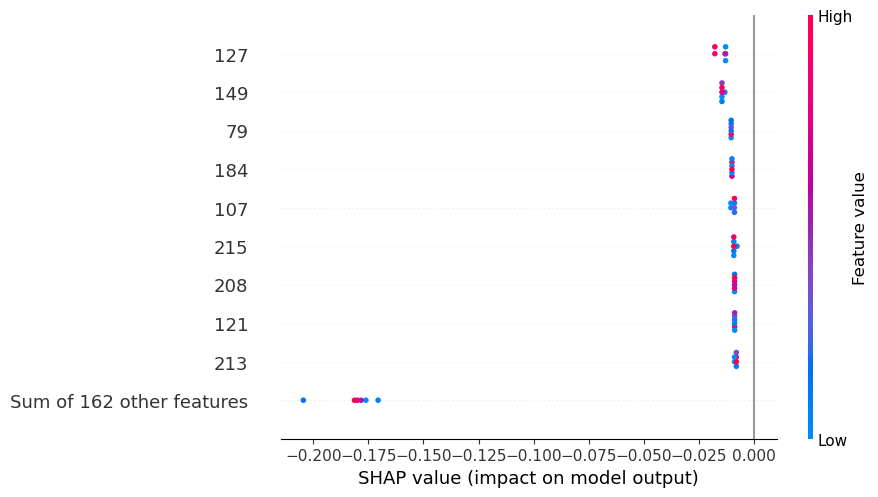

In [114]:
from mlbiosig.evaluate import plot_shap_beeswarm, plot_shap_dependence

plot_shap_beeswarm(models, X_test, model="Random Forest")

The beeswarm plot above shows that both high and low intensity values of several $m/z$ features drive abiotic predictions, and builds on the permutation feature importance analysis for RF. For example, $m/z$ $149$ with a median F1 score drop of $0.3$ appears to drive abiotic predictions in the SHAP plot, while $m/z$ $127$ with varying permutation importance corresponds to abiotic predictions at both high and low intensities across the sample set. However, given RF's limited generalisation to the unseen testing set (F1 score of $0.40$), these $m/z$ interpretations should be explored with caution.

### Summary:

`mlbiosig` offers a flexible approach to automated feature construction, cleaning, and engineering from raw mass spectra sample data stored in CSV files. Four models are hyperparameter tuned, trained, and evaluated within a single workflow as well, enabling for domain scientists to focus on the interpretation of results. Permutation feature importance scores across all models allows for a model-agnostic starting point, in order to identify the $m/z$ fragment ions that most influence correct ML predictions. Coefficient analysis (linear models) and SHAP (tree-based non-linear models) then reveal the direction of these contributions, in terms of whether a fragment ion drives biotic or abiotic predictions and under what abundances. These tools combined expose the geochemical processes supporting model predictions, and therefore translate classifier behaviour into chemically-informed insights that are accessible to geochemists and astrobiologists without ML expertise.